# Canon First corrected dual-chart rerun
Pure in-memory execution of the packaged live relation and controls. No file I/O.


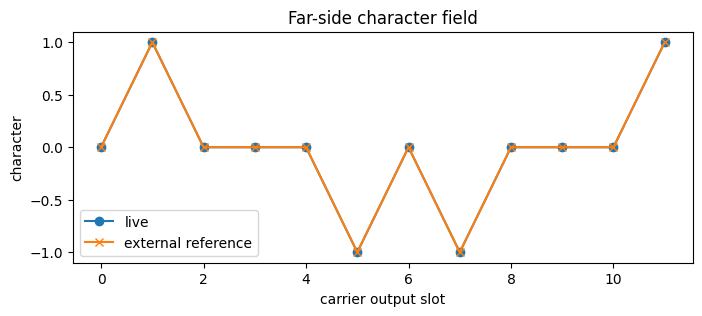

PASS {'mismatches': 0, 'channels': 12}


In [1]:
import matplotlib.pyplot as plt
from orthad_canon import run_once, RunOptions
from orthad_canon.meta.verify import compare_evidence, evidence_gate
state = run_once()
rows = compare_evidence(state)
actual = [r['character_value'] for r in rows]
expected = [r['character_reference'] for r in rows]
plt.figure(figsize=(8,3))
plt.plot(range(12), actual, marker='o', label='live')
plt.plot(range(12), expected, marker='x', label='external reference')
plt.legend()
plt.title('Far-side character field')
plt.xlabel('carrier output slot')
plt.ylabel('character')
plt.show()
mismatches = sum(a != b for a,b in zip(actual, expected))
print('PASS' if evidence_gate(state) else 'FAIL', {'mismatches': mismatches, 'channels': len(rows)})


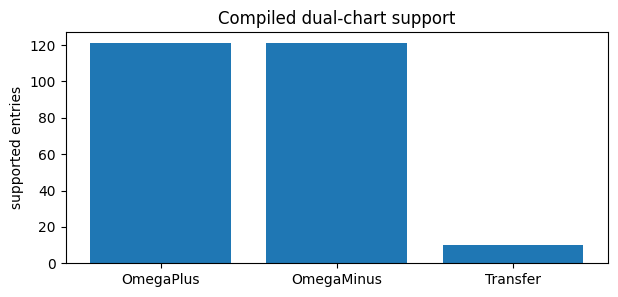

PASS {'support_counts': [121, 121, 10], 'event_count': 2}


In [2]:
lens = state.lens
counts = [sum(e.support for row in lens.omega_plus for e in row), sum(e.support for row in lens.omega_minus for e in row), sum(e.support for row in lens.transfer_plus_to_minus for e in row)]
plt.figure(figsize=(7,3))
plt.bar(['OmegaPlus','OmegaMinus','Transfer'], counts)
plt.title('Compiled dual-chart support')
plt.ylabel('supported entries')
plt.show()
passed = bool(lens.omega_plus) and bool(lens.omega_minus) and counts[2] > 0
print('PASS' if passed else 'FAIL', {'support_counts': counts, 'event_count': lens.event_count})


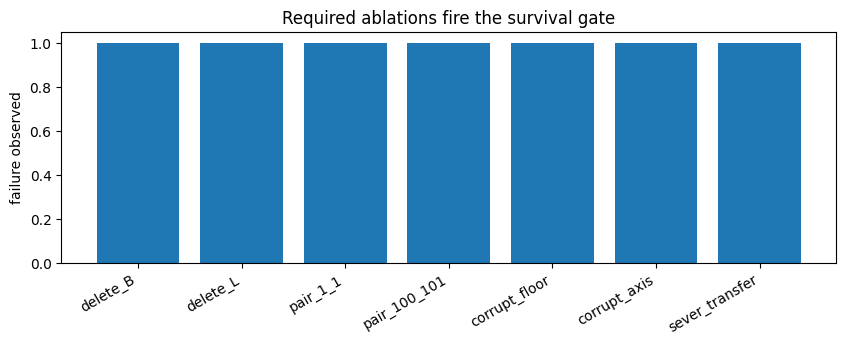

PASS {'failed_as_required': 7, 'required': 7}


In [3]:
cases = {
 'delete_B': RunOptions(delete_b=True),
 'delete_L': RunOptions(delete_l=True),
 'pair_1_1': RunOptions(pair_override=(1,1)),
 'pair_100_101': RunOptions(pair_override=(100,101)),
 'corrupt_floor': RunOptions(corrupt_floor_bit=True),
 'corrupt_axis': RunOptions(corrupt_latched_axis=True),
 'sever_transfer': RunOptions(sever_cross_transfer=True),
}
failure_flags = [not evidence_gate(run_once(opt)) for opt in cases.values()]
plt.figure(figsize=(10,3))
plt.bar(list(cases), [int(v) for v in failure_flags])
plt.xticks(rotation=30, ha='right')
plt.title('Required ablations fire the survival gate')
plt.ylabel('failure observed')
plt.show()
print('PASS' if all(failure_flags) else 'FAIL', {'failed_as_required': sum(failure_flags), 'required': len(failure_flags)})


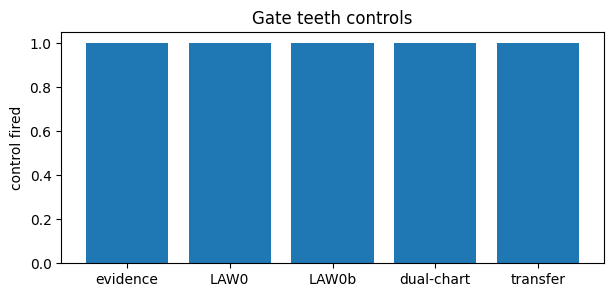

PASS {'controls_fired': 5, 'controls': 5}


In [4]:
from orthad_canon.meta.verify import evidence_control, source_control, scalar_control, dual_chart_control, transfer_control
controls = [evidence_control(state), source_control(), scalar_control(), dual_chart_control(state), transfer_control(state)]
plt.figure(figsize=(7,3))
plt.bar(['evidence','LAW0','LAW0b','dual-chart','transfer'], [int(v) for v in controls])
plt.title('Gate teeth controls')
plt.ylabel('control fired')
plt.show()
print('PASS' if all(controls) else 'FAIL', {'controls_fired': sum(controls), 'controls': len(controls)})
